<a href="https://colab.research.google.com/github/MeerabKhan123/ABSTRACTION-ENCAPSULATION/blob/main/Hackhton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fraud Detection**

**Import Library**

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

**Read Data**

In [83]:
df=pd.read_csv("/content/Synthetic_Financial_datasets_log.csv")
print(df)

         step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1              19384.72  M2044282

**EDA**

In [84]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [85]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [86]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [87]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [88]:
df.shape

(6362620, 11)

In [89]:
df.size

69988820

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [91]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [92]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df.fillna(0)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


# **Visualization**

**Styling**

In [95]:
sns.set_theme(style="darkgrid")

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14

**Count Plot**

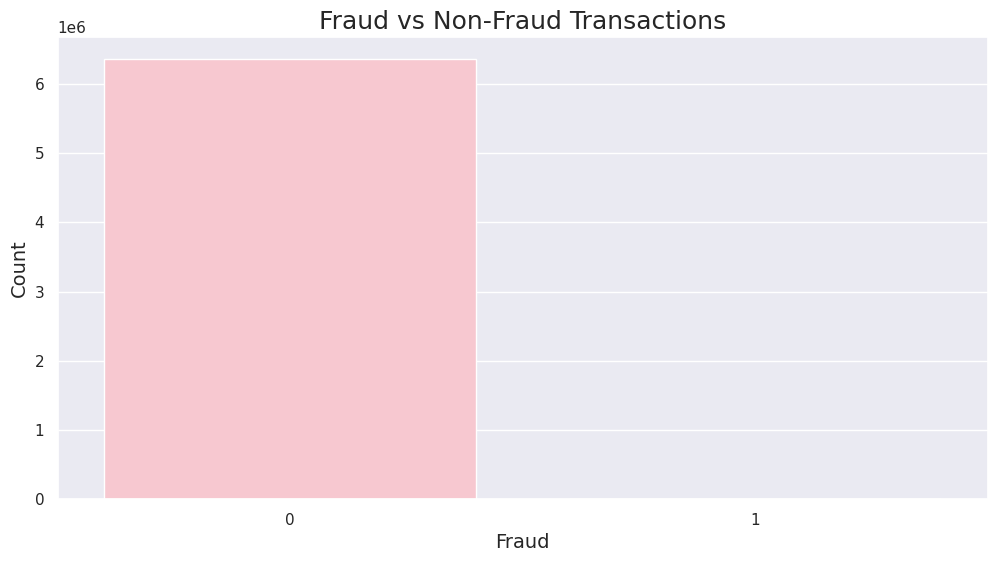

In [96]:
sns.countplot(x='isFraud', data=df,color='pink')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

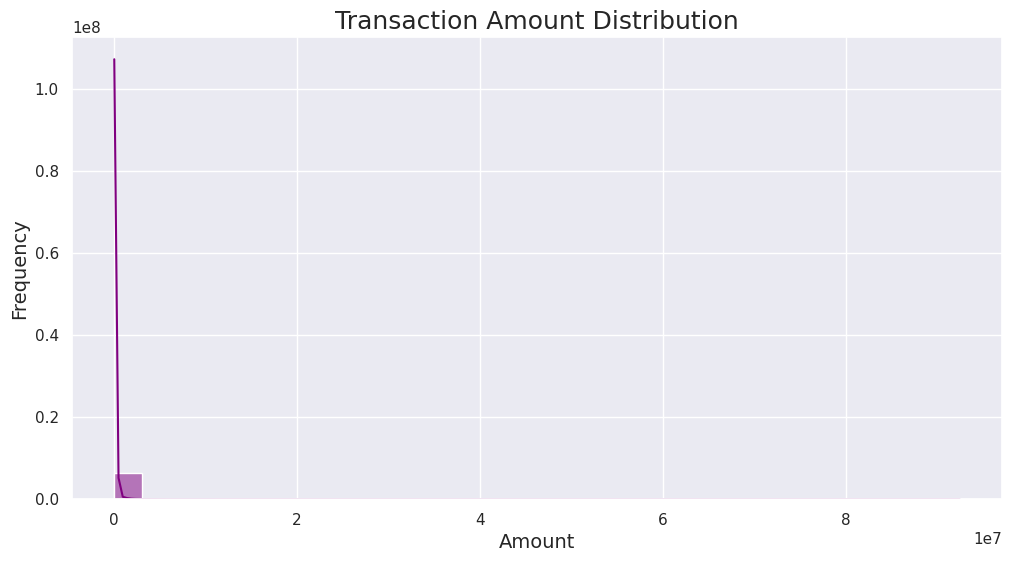

In [97]:
sns.histplot(
    df['amount'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

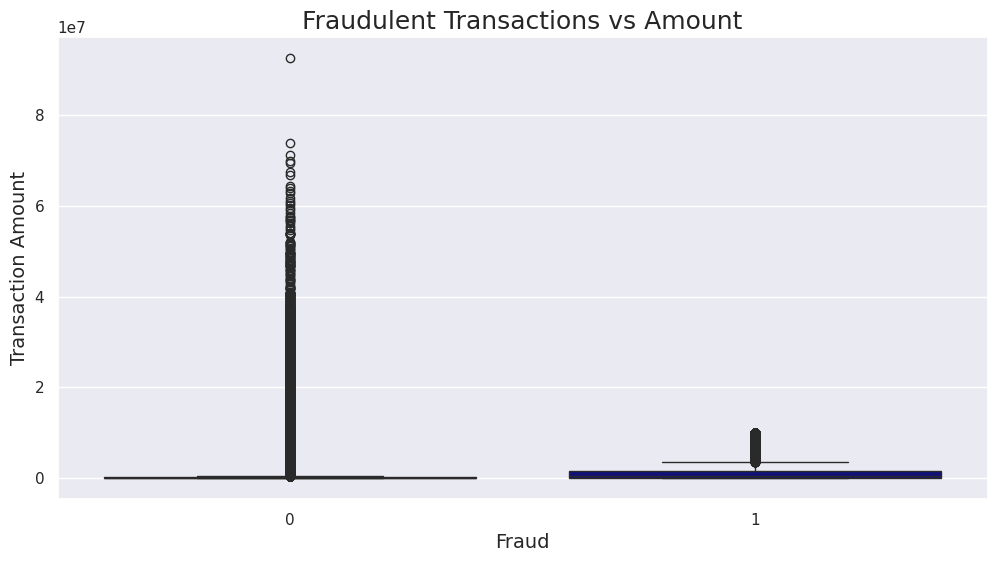

In [98]:
sns.boxplot(
    x='isFraud',
    y='amount',
    data=df,
    color='darkblue'
)

plt.title("Fraudulent Transactions vs Amount")
plt.xlabel("Fraud")
plt.ylabel("Transaction Amount")
plt.show()

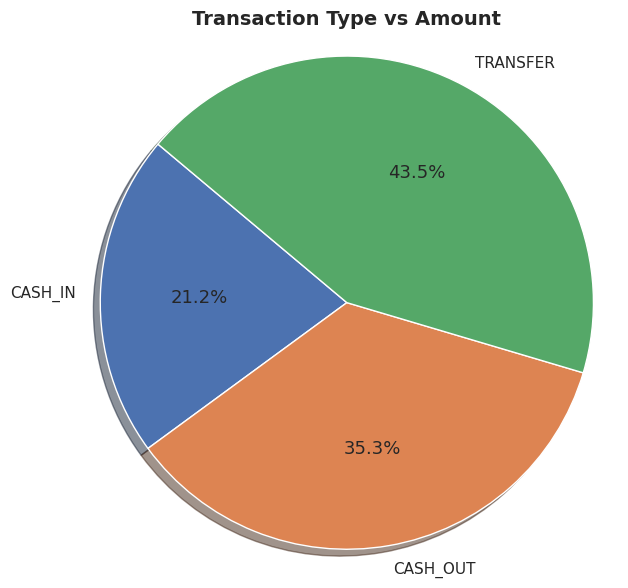

In [99]:
type_amount = df.groupby('type')['amount'].sum()
type_amount = type_amount.drop(['PAYMENT', 'DEBIT'])

plt.figure(figsize=(7,7))

plt.pie(type_amount,
        labels=type_amount.index,
        autopct='%1.1f%%',
        startangle=140,
        shadow=True,
        wedgeprops={'edgecolor': 'white'})

plt.title('Transaction Type vs Amount', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

# **Logistic Regresssion**

In [100]:
X = df[['amount', 'type']]
y = df['isFraud']

In [101]:
X = pd.get_dummies(X, columns=['type'], drop_first=True)

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

In [103]:
print(y_train.isnull().sum())

0


In [104]:
data = pd.concat([X, y], axis=1)

data = data.dropna()

X = data.drop('isFraud', axis=1)
y = data['isFraud']

In [105]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [106]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [107]:
y_pred=model.predict(X_test)

In [ ]:
y_prob=model.predict_proba(X_test)

In [ ]:
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 confusion_matrix,
 classification_report
)

In [110]:
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("ROC AUC Score:",roc_auc_score(y_test, y_prob[:, 1]))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))

Accuracy: 0.9987154138808646
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC Score: 0.8870438741823388
Confusion Matrix:
 [[1906334      17]
 [   2435       0]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906351
           1       0.00      0.00      0.00      2435

    accuracy                           1.00   1908786
   macro avg       0.50      0.50      0.50   1908786
weighted avg       1.00      1.00      1.00   1908786



# **Decision Tree**


In [111]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [112]:
y_pred = model.predict(X_test)

In [113]:
y_prob=model.predict_proba(X_test)

In [114]:
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 confusion_matrix,
 classification_report
)

In [115]:
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("ROC AUC Score:",roc_auc_score(y_test, y_prob[:, 1]))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))

Accuracy: 0.9978688024744523
Precision: 0.1541719610334604
Recall: 0.14948665297741273
F1 Score: 0.1517931609674729
ROC AUC Score: 0.5819826788492684
Confusion Matrix:
 [[1904354    1997]
 [   2071     364]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906351
           1       0.15      0.15      0.15      2435

    accuracy                           1.00   1908786
   macro avg       0.58      0.57      0.58   1908786
weighted avg       1.00      1.00      1.00   1908786



In [116]:
model_pre = DecisionTreeClassifier(max_depth=4)
model_pre.fit(X_train , y_train)

y_pred_pre = model_pre.predict(X_test)
print("Pre Pruning Accuracy",accuracy_score(y_test,y_pred_pre))

Pre Pruning Accuracy 0.9988877747426899


In [117]:
model_post= DecisionTreeClassifier(ccp_alpha=0.01)
model_post.fit(X_train , y_train)


y_pred_post = model_post.predict(X_test)
print("Post Pruning Accuracy",accuracy_score(y_test,y_pred_post))

Post Pruning Accuracy 0.9987243200652143


# **Random Forest**

In [ ]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_prob=model.predict_proba(X_test)

In [118]:
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 confusion_matrix,
 classification_report
)

In [119]:
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("ROC AUC Score:",roc_auc_score(y_test, y_prob[:, 1]))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))

Accuracy: 0.9978688024744523
Precision: 0.1541719610334604
Recall: 0.14948665297741273
F1 Score: 0.1517931609674729
ROC AUC Score: 0.5819826788492684
Confusion Matrix:
 [[1904354    1997]
 [   2071     364]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906351
           1       0.15      0.15      0.15      2435

    accuracy                           1.00   1908786
   macro avg       0.58      0.57      0.58   1908786
weighted avg       1.00      1.00      1.00   1908786



# **Final Result**